In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/german_credit_data.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


### Data Overview

Let's get some basic information about the dataset, such as data types, non-null values, and summary statistics, to understand its characteristics and identify any potential issues.

In [2]:
# Display concise summary of the DataFrame
display(df.info())

# Display descriptive statistics
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


None

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


### Preprocessing: Handling Missing Values and Redundant Columns

First, I'll drop the redundant 'Unnamed: 0' column. Then, for the 'Saving accounts' and 'Checking account' columns with missing values, a common strategy for categorical features is to fill them with a placeholder like 'No Info' or the mode. Given these are financial accounts, 'No Info' might be more appropriate to indicate the absence of information rather than assuming a common category. For simplicity in this initial model, let's fill them with 'No Info'.

In [3]:
# Drop the 'Unnamed: 0' column as it appears to be an artifact of the dataset
df = df.drop('Unnamed: 0', axis=1)

# Fill missing values in 'Saving accounts' and 'Checking account' with 'No Info'
df['Saving accounts'] = df['Saving accounts'].fillna('No Info')
df['Checking account'] = df['Checking account'].fillna('No Info')

# Display the count of missing values after treatment to verify
print("Missing values after filling:")
print(df.isnull().sum())

Missing values after filling:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


### Preprocessing: Encoding Categorical Features

Next, we need to convert the categorical features into a numerical format that machine learning models can understand. For nominal categorical variables (like `Sex`, `Housing`, `Purpose`, `Saving accounts`, `Checking account`), one-hot encoding is a suitable method. The `Risk` column is our target variable, which is also categorical ('good'/'bad'). We will encode it as 0 and 1, where 'bad' credit risk will be encoded as 1 (positive class).

In [4]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns for one-hot encoding (excluding the target variable 'Risk')
categorical_cols = ['Sex', 'Housing', 'Purpose', 'Saving accounts', 'Checking account']

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Encode the target variable 'Risk' (good: 0, bad: 1)
label_encoder = LabelEncoder()
df_encoded['Risk'] = label_encoder.fit_transform(df_encoded['Risk'])

# Display the first few rows of the encoded DataFrame and its info to verify
display(df_encoded.head())
print("\nInfo after encoding:")
display(df_encoded.info())

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,...,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_little,Checking account_moderate,Checking account_rich
0,67,2,1169,6,1,True,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,22,2,5951,48,0,False,True,False,False,False,...,True,False,False,True,False,False,False,False,True,False
2,49,1,2096,12,1,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,45,2,7882,42,1,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,53,2,4870,24,0,True,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False



Info after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          1000 non-null   int64
 1   Job                          1000 non-null   int64
 2   Credit amount                1000 non-null   int64
 3   Duration                     1000 non-null   int64
 4   Risk                         1000 non-null   int64
 5   Sex_male                     1000 non-null   bool 
 6   Housing_own                  1000 non-null   bool 
 7   Housing_rent                 1000 non-null   bool 
 8   Purpose_car                  1000 non-null   bool 
 9   Purpose_domestic appliances  1000 non-null   bool 
 10  Purpose_education            1000 non-null   bool 
 11  Purpose_furniture/equipment  1000 non-null   bool 
 12  Purpose_radio/TV             1000 non-null   bool 
 13  Purpose_repairs            

None

### Preprocessing: Feature Scaling

Now, let's scale the numerical features. This is important for algorithms that are sensitive to the magnitude of feature values. We'll use `StandardScaler` to transform the numerical features so they have a mean of 0 and a standard deviation of 1.

In [5]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns (excluding the target variable 'Risk')
numerical_cols = ['Age', 'Credit amount', 'Duration', 'Job'] # 'Job' is also numerical here after initial inspection

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical columns
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

# Display the first few rows of the scaled DataFrame to verify
display(df_encoded.head())

,Age,Job,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,...,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Checking account_little,Checking account_moderate,Checking account_rich
0,2.766456,0.146949,-0.745131,-1.236478,1,True,True,False,False,False,...,True,False,False,False,False,False,False,True,False,False
1,-1.191404,0.146949,0.949817,2.248194,0,False,True,False,False,False,...,True,False,False,True,False,False,False,False,True,False
2,1.183312,-1.383771,-0.416562,-0.738668,1,True,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3,0.831502,0.146949,1.634247,1.750384,1,True,False,False,False,False,...,False,False,False,True,False,False,False,True,False,False
4,1.535122,0.146949,0.566664,0.256953,0,True,False,False,True,False,...,False,False,False,True,False,False,False,True,False,False


### Data Splitting

Finally, we will split the preprocessed data into features (X) and target (y), and then further divide them into training and testing sets. This will allow us to train our model on one portion of the data and evaluate its performance on unseen data.

In [6]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_encoded.drop('Risk', axis=1)
y = df_encoded['Risk']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (800, 21)
X_test shape: (200, 21)
y_train shape: (800,)
y_test shape: (200,)


### Model Building: Logistic Regression

Now, we'll train a Logistic Regression model using our prepared training data. Logistic Regression is a good starting point for binary classification problems like credit risk prediction.

In [7]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets

# Train the model on the training data
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


### Model Evaluation

After training, it's crucial to evaluate the model's performance on the unseen test data. We'll look at several metrics to understand how well our model predicts credit risk:

*   **Accuracy**: Overall correctness of the model.
*   **Precision**: Ability of the model to avoid false positives (how many selected items are relevant).
*   **Recall**: Ability of the model to find all the relevant cases (how many relevant items are selected).
*   **F1-Score**: Harmonic mean of precision and recall.
*   **ROC AUC Score**: Measures the ability of the model to distinguish between classes.

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Predict on the test set
y_pred = log_reg_model.predict(X_test)
y_pred_proba = log_reg_model.predict_proba(X_test)[:, 1] # Probability of default (class 1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Display the metrics
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Display Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7300
Precision: 0.7756
Recall: 0.8643
F1-Score: 0.8176
ROC AUC Score: 0.7486

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.42      0.48        60
           1       0.78      0.86      0.82       140

    accuracy                           0.73       200
   macro avg       0.67      0.64      0.65       200
weighted avg       0.71      0.73      0.72       200


Confusion Matrix:
[[ 25  35]
 [ 19 121]]


### Probability of Default and Credit Ratings

The Logistic Regression model directly outputs the probability of belonging to each class. For credit risk, we are primarily interested in the probability of default (P(Risk=1)). We can then use these probabilities to assign credit ratings or risk categories. For demonstration, let's define some simple thresholds to categorize risk.

In [9]:
# Predict probability of default (class 1)
prob_default = log_reg_model.predict_proba(X_test)[:, 1]

# Create a DataFrame for test predictions
predictions_df = pd.DataFrame({
    'Actual_Risk': y_test,
    'Predicted_Risk': y_pred,
    'Probability_Default': prob_default
})

# Define simple credit risk categories based on probability of default
def assign_credit_rating(prob):
    if prob <= 0.25:
        return 'Low Risk (A)'
    elif prob <= 0.50:
        return 'Medium Risk (B)'
    elif prob <= 0.75:
        return 'High Risk (C)'
    else:
        return 'Very High Risk (D)'

predictions_df['Credit_Rating'] = predictions_df['Probability_Default'].apply(assign_credit_rating)

# Display the first few predictions with assigned ratings
display(predictions_df.head())

# Display the distribution of assigned credit ratings
print("\nDistribution of Credit Ratings:")
display(predictions_df['Credit_Rating'].value_counts())

,Actual_Risk,Predicted_Risk,Probability_Default,Credit_Rating
977,1,1,0.791277,Very High Risk (D)
735,1,0,0.412607,Medium Risk (B)
615,1,1,0.585853,High Risk (C)
413,1,1,0.890977,Very High Risk (D)
563,0,1,0.524663,High Risk (C)



Distribution of Credit Ratings:


,count
Credit_Rating,
Very High Risk (D),85
High Risk (C),71
Medium Risk (B),40
Low Risk (A),4


### Visualization: Distribution of Credit Ratings

Let's visualize the distribution of the assigned credit ratings to see the proportion of customers in each risk category.

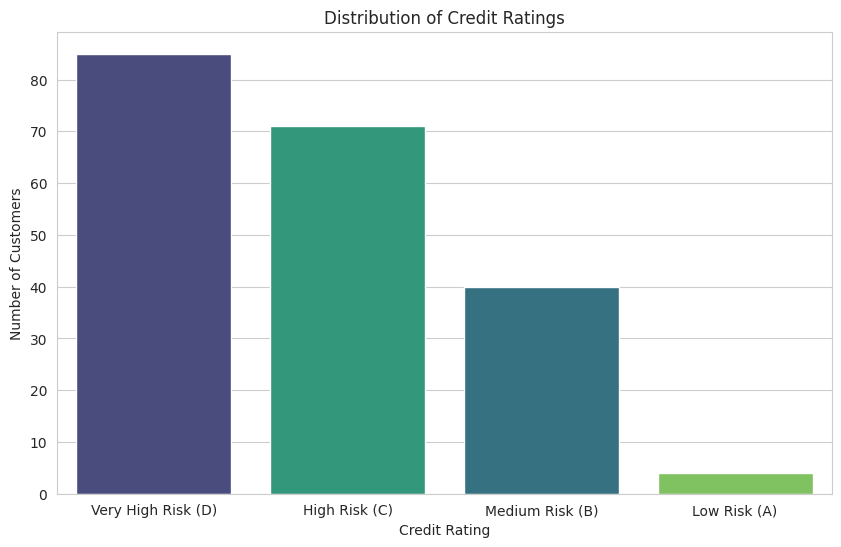

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better aesthetics
sns.set_style('whitegrid')

# Create a bar plot for the distribution of Credit Ratings
plt.figure(figsize=(10, 6))
sns.countplot(x='Credit_Rating', data=predictions_df, palette='viridis', order=predictions_df['Credit_Rating'].value_counts().index, hue='Credit_Rating', legend=False)
plt.title('Distribution of Credit Ratings')
plt.xlabel('Credit Rating')
plt.ylabel('Number of Customers')
plt.show()

### Visualization: Confusion Matrix Heatmap

To better understand the model's performance, especially in terms of true positives, true negatives, false positives, and false negatives, let's visualize the confusion matrix as a heatmap.

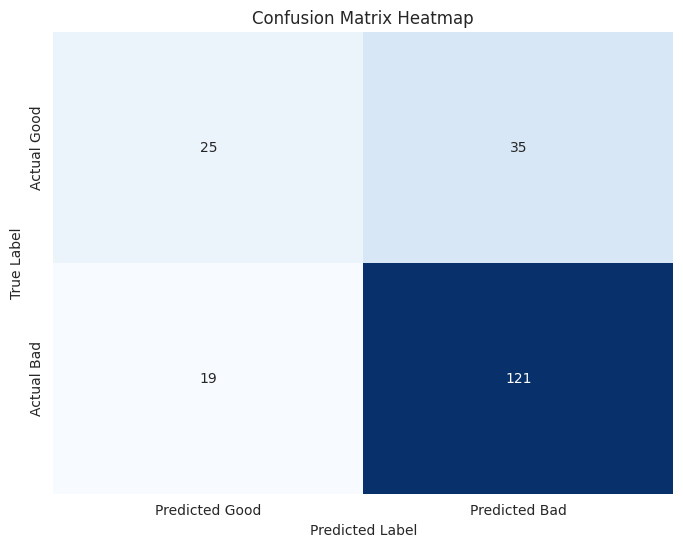

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Recalculate the confusion matrix (it was already printed, but for the heatmap, we'll get it again)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Good', 'Predicted Bad'],
            yticklabels=['Actual Good', 'Actual Bad'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### ROC Curve and AUC

The Receiver Operating Characteristic (ROC) curve is a graphical plot that illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied. The Area Under the Curve (AUC) represents the degree or measure of separability. It tells how much the model is capable of distinguishing between classes. Higher AUC means the model is better at predicting 0s as 0s and 1s as 1s.

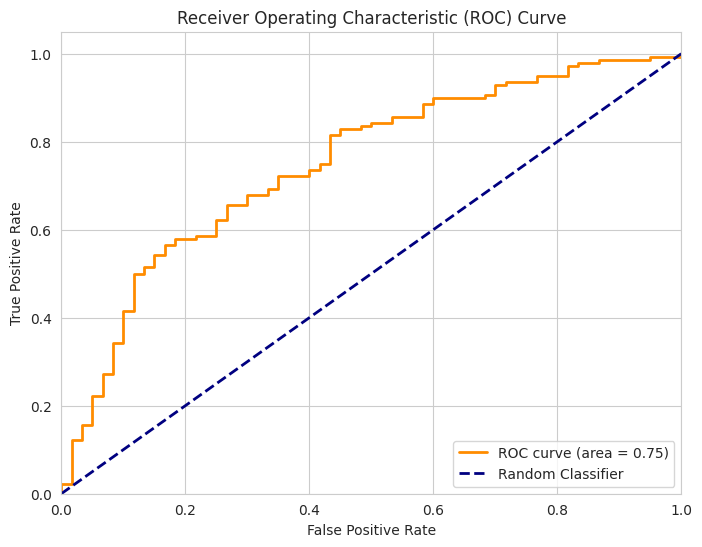

ROC AUC Score: 0.7486


In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")

### Summary and Next Steps

We have successfully:

1.  **Loaded and Preprocessed Data**: Handled missing values, encoded categorical features, and scaled numerical features.
2.  **Split Data**: Created training and testing sets.
3.  **Built and Evaluated Logistic Regression Model**: Assessed its performance using accuracy, precision, recall, F1-score, and ROC AUC.
4.  **Predicted Probability of Default**: Generated probabilities for the test set.
5.  **Assigned Credit Ratings/Risk Categories**: Categorized customers based on their probability of default.

This completes the requested steps for building a credit risk model to predict the probability of default, assign credit ratings, and categorize risks using logistic regression. For a more comprehensive 'Expected Loss' calculation, additional data on Exposure at Default (EAD) and Loss Given Default (LGD) would be required.